<h1>
    Compare prediction error with declared error in different goodness
</h1>

In [2]:
import os
import sys

import numpy as np

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)


In [3]:
from src.models.data_selection.data_selector import Data_selector
from src.models.utils import *
import matplotlib.pyplot as plt

In [4]:
csv_read_path = os.path.join(project_root, "data", "processed", "with_prediction.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')
df.dropna(subset=["generation", "prediction", "declared"], inplace=True)


In [5]:
declared_errors1, pred_errors1, data_sizes = [], [], []

all_goodness = [0,1,2,3,5]
for goodness in all_goodness:
    df_selected = Data_selector(df).select_peaks(goodness=goodness)
    generation = df_selected["generation"]
    prediction = df_selected["prediction"]
    declared = df_selected["declared"]
    
    pred_error1 = compute_relative_rmse(generation, prediction)
    declared_error1 = compute_relative_rmse(generation, declared)
    
    pred_errors1.append(pred_error1)
    declared_errors1.append(declared_error1)
    
    data_sizes.append(len(generation))
    

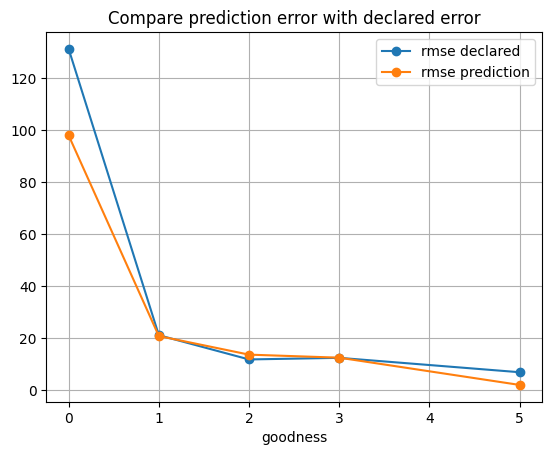

In [12]:
plt.plot(all_goodness, declared_errors1, label="rmse declared", marker="o")
plt.plot(all_goodness, pred_errors1, label="rmse prediction", marker="o")
plt.title("Compare prediction error with declared error")
plt.xlabel("goodness")
#plt.yticks(np.arange(0,100,1))
plt.grid()
plt.legend()
plt.show()

In [121]:
def percenatge_bigger(g,p):
    n1 = np.count_nonzero((g>p).values)
    return n1/len(g)

In [122]:
declared_errors1, pred_errors1, data_sizes = [], [], []
declared_errors2, pred_errors2 = [], []

all_goodness = [0,1,2,3,5]
for goodness in all_goodness:
    df_selected = Data_selector(df).select_peaks(goodness=goodness)
    generation = df_selected["generation"]
    prediction = df_selected["prediction"]
    declared = df_selected["declared"]
    
    pred_error1 = percenatge_bigger(generation, prediction)
    declared_error1 = percenatge_bigger(generation, declared)
    
    pred_error2 = percenatge_bigger(generation+2, prediction)
    declared_error2 = percenatge_bigger(generation+2, declared)
    
    pred_errors1.append(pred_error1)
    declared_errors1.append(declared_error1)
    
    pred_errors2.append(pred_error2)
    declared_errors2.append(declared_error2)
    
    data_sizes.append(len(generation))
    

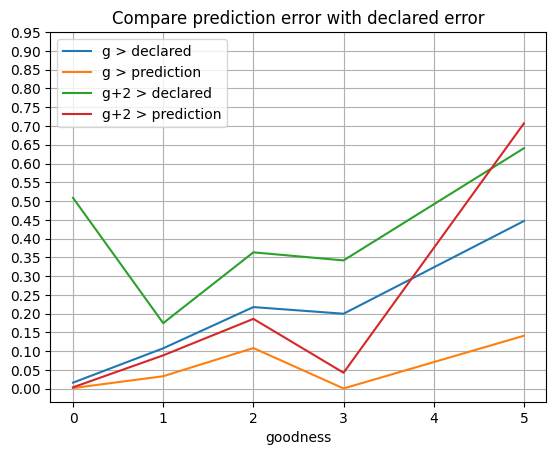

In [125]:
plt.plot(all_goodness, declared_errors1, label="g > declared")
plt.plot(all_goodness, pred_errors1, label="g > prediction")
plt.plot(all_goodness, declared_errors2, label="g+2 > declared")
plt.plot(all_goodness, pred_errors2, label="g+2 > prediction")
plt.title("Compare prediction error with declared error")
plt.xlabel("goodness")
plt.yticks(np.arange(0,1,0.05))
plt.grid()
plt.legend()
plt.show()

In [131]:
declared_errors1, pred_errors1, data_sizes = [], [], []
declared_errors2, pred_errors2 = [], []

all_goodness = [0,1,2,4,6]
for goodness in all_goodness:
    df_selected = Data_selector(df).select_peaks(goodness=goodness)
    generation = df_selected["generation"]
    prediction = df_selected["prediction_turbo"]
    declared = df_selected["declared"]
    
    pred_error1 = percenatge_bigger(generation-1, prediction)
    declared_error1 = percenatge_bigger(generation-1, declared)
    
    pred_error2 = percenatge_bigger(generation+1, prediction)
    declared_error2 = percenatge_bigger(generation+1, declared)
    
    pred_errors1.append(pred_error1)
    declared_errors1.append(declared_error1)
    
    pred_errors2.append(pred_error2)
    declared_errors2.append(declared_error2)
    
    data_sizes.append(len(generation))
    

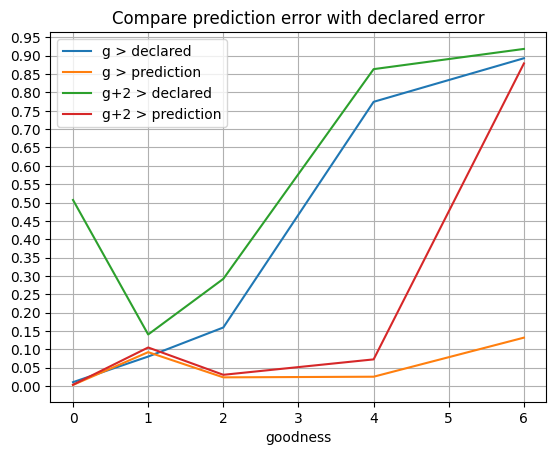

In [132]:
plt.plot(all_goodness, declared_errors1, label="g > declared")
plt.plot(all_goodness, pred_errors1, label="g > prediction")
plt.plot(all_goodness, declared_errors2, label="g+2 > declared")
plt.plot(all_goodness, pred_errors2, label="g+2 > prediction")
plt.title("Compare prediction error with declared error")
plt.xlabel("goodness")
plt.yticks(np.arange(0,1,0.05))
plt.grid()
plt.legend()
plt.show()